<a href="https://colab.research.google.com/github/NeevWadhwa-Helloworld/Machine-Learning-Projects/blob/main/Gold_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Gold Price Prediction**

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

In [4]:
df=yf.download("Gold",start='2020-03-11',end='2026-03-11',progress=False)
df.head()

Price,Close,High,Low,Open,Volume
Ticker,GOLD,GOLD,GOLD,GOLD,GOLD
Date,,,,,
2020-03-11,3.466066,3.539411,3.404004,3.404004,10600
2020-03-12,3.257311,3.385196,3.054199,3.385196,30000
2020-03-13,3.340061,3.396481,2.913150,3.328401,45200
2020-03-16,3.486753,3.486753,3.178324,3.246028,36000
2020-03-17,3.309970,3.460423,3.234743,3.460423,34600


In [6]:
df['Return']=df[('Close', 'GOLD')].pct_change()*100
df['Lagged_Return']=df.Return.shift()
df=df.dropna()
train=df['2001':'2021']
test=df['2022':'2023']
#Create train and test sets for dependent and independent variables
X_train=train["Lagged_Return"].to_frame()
y_train=train["Return"]
X_test=test["Lagged_Return"].to_frame()
y_test=test["Return"]

## **Using Linear Regression Model**

In [7]:
model=LinearRegression()
model.fit(X_train,y_train)
predictions=model.predict(X_test)

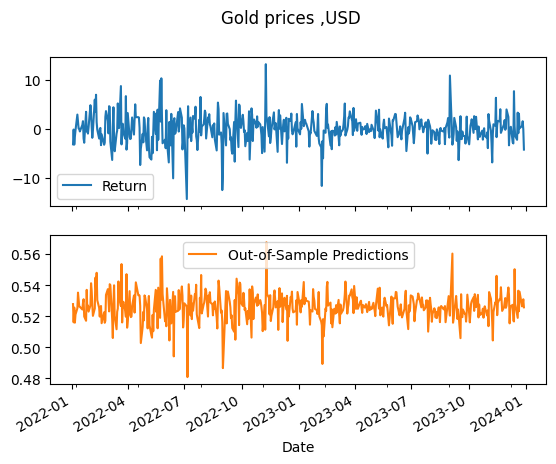

In [8]:
import matplotlib.pyplot as plt
out_of_sample_results=y_test.to_frame()
out_of_sample_results['Out-of-Sample Predictions']=model.predict(X_test)
out_of_sample_results.plot(subplots=True,title="Gold prices ,USD")
plt.show()